# University Communications Intelligence
## Week 2: Data Collection, Text Extraction & Preprocessing

**Project Objective:**  
University communications—including official circulars, examination notifications, academic schedules, hostel seniority lists, and administrative orders—are critical institutional records that must be systematically indexed, categorized, and targeted to appropriate stakeholders. 

This notebook documents the **Week 2 dataset preparation stage**:
1. Data collection of public university communication PDFs across multiple institutions.
2. Digital text extraction and OCR recovery of scanned notices.
3. Text normalization and layout artifact cleaning.
4. Annotation schema for Category (single-label) and Audience (multi-label).
5. Train/Validation/Test data splitting and dataset health analysis.


In [1]:
import json
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Resolve canonical dataset path robustly
candidates = [
    Path("data/processed/classification_dataset/classification_dataset.csv"),
    Path("../../data/processed/classification_dataset/classification_dataset.csv"),
]
dataset_path = next((p for p in candidates if p.is_file()), None)
if dataset_path is None:
    raise FileNotFoundError("Could not find classification_dataset.csv in expected locations.")

print(f"Loading canonical dataset from: {dataset_path.resolve()}")
df = pd.read_csv(dataset_path)
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")


Loading canonical dataset from: /Users/adilsyed/Developer/Machine Learning/uni-comms-intelligence/data/processed/classification_dataset/classification_dataset.csv
Dataset shape: 150 rows, 15 columns


### 2. Dataset Schema & Sample Records
The dataset contains authoritative notice IDs, source university metadata, category labels (with documented audit corrections), audience labels, and normalized `cleaned_text`.


In [2]:
# Display column names and sample rows
print("Columns in canonical dataset:")
for col in df.columns:
    print(f" - {col}")

display_cols = ["notice_id", "university", "title", "category", "audience_labels", "split", "is_synthetic"]
df[display_cols].head(5)


Columns in canonical dataset:
 - notice_id
 - document_id
 - university
 - title
 - category
 - original_category
 - corrected_category
 - correction_reason
 - audience_labels
 - audience_label_source
 - is_synthetic
 - split
 - cleaned_text
 - source_url
 - recovery_method


,notice_id,university,title,category,audience_labels,split,is_synthetic
0,CIRC-2026-0001,University of Lucknow,Trial Notice for Hockey (Men/Women),general,"[""students""]",test,False
1,CIRC-2026-0003,University of Lucknow,Strict Compliance with UGC Regulations 2009 fo...,general,"[""students"", ""faculty"", ""administrators""]",test,False
2,CIRC-2026-0004,University of Lucknow,"Trial Notice for Chess, Kabaddi and Cross Coun...",general,"[""students""]",train,False
3,CIRC-2026-0007,University of Lucknow,Appointment of Provosts and Assistant Provosts...,general,"[""faculty"", ""administrators""]",val,False
4,CIRC-2026-0010,University of Lucknow,Notice for Direct Admission under Sports Quota...,admission,"[""students""]",test,False


### 3. Data Collection & Extraction Overview
- **Raw PDFs collected:** 133 PDF files gathered from public institutional portals:
  - Banaras Hindu University (BHU)
  - Jawaharlal Nehru University (JNU)
  - University of Lucknow
  - Indian Institute of Technology Bombay (IIT Bombay)
- **Extraction Challenge:** Native PDF extraction (`pypdf`) extracted digital text for 75 notices, but **48 notices were scanned/image-only PDFs** with zero text layer (e.g. 10/10 examination notices and 23/25 general notices).
- **OCR Recovery:** Native macOS Apple Vision OCR (`VNRecognizeTextRequest`) recovered **42 real documents**, and 3 bilingual circulars with English bodies were verified, bringing the usable real document count to **120 real university communications** (a 60% expansion).
- **Synthetic Augmentation:** 30 realistic institutional circular templates were generated strictly for training to balance long-tail classes (e.g. announcements, administrative circulars).


In [3]:
# Recovery and source composition
recovery_counts = df["recovery_method"].value_counts()
real_synth_counts = df["is_synthetic"].value_counts().rename({False: "Real Documents", True: "Synthetic Augmentation"})

print("Document Recovery Composition:")
print(recovery_counts)
print("\nReal vs. Synthetic:")
print(real_synth_counts)


Document Recovery Composition:
recovery_method
native_pypdf                75
apple_vision_ocr            42
synthetic_augmentation      30
bilingual_clean_recovery     3
Name: count, dtype: int64

Real vs. Synthetic:
is_synthetic
Real Documents            120
Synthetic Augmentation     30
Name: count, dtype: int64


### 4. Text Normalization & Cleaning
Raw PDF extractions often contain severe layout artifacts:
- Arbitrary mid-sentence line breaks from column formatting.
- Hyphenated words split across lines (`regis-\ntration` $\to$ `registration`).
- Running headers/footers repeated across multiple pages (`Page X of Y`, institution stamps).
- Control characters and non-printable Unicode symbols.

The pipeline applies deterministic, non-destructive normalization (`scripts/preprocess.py`) to produce `cleaned_text`:
1. **NFKC Unicode Normalization**: Standardizes character representations.
2. **Margin Stripping**: Removes headers/footers occurring in the top/bottom 2 lines of $\ge 2$ pages.
3. **Broken Hyphen Rejoin**: Unwraps split words (`(?<=\\w)-\\n(?=\\w)`).
4. **Linebreak Unwrapping**: Unwraps sentence fragments when not preceded by terminal punctuation (`(?<![.!?:;])\\n(?=[a-z])`).
5. **Whitespace Collapse**: Collapses excessive blank lines (`\\n{3,}` $\to$ `\\n\\n`).


In [4]:
# Text length statistics
df["char_count"] = df["cleaned_text"].apply(len)
df["word_count"] = df["cleaned_text"].apply(lambda t: len(t.split()))

print("Cleaned Text Summary Statistics:")
print(df[["char_count", "word_count"]].describe().round(1))

# Display a representative snippet
sample_notice = df[df["category"] == "academic"].iloc[0]
print(f"\nSample Notice [{sample_notice['notice_id']} - {sample_notice['title']}]:")
print("-" * 60)
print(sample_notice["cleaned_text"][:350] + "...")


Cleaned Text Summary Statistics:
       char_count  word_count
count       150.0       150.0
mean      16519.4      2733.8
std       51702.8      8811.9
min         293.0        45.0
25%         914.8       136.8
50%        1700.5       258.5
75%        7522.0      1152.2
max      406867.0     69831.0

Sample Notice [CIRC-2026-0022 - Extension of date for Add/Drop courses for newly admitted students for Monsoon Semester 2026]:
------------------------------------------------------------
Jawaharlal Nehru University
4 Elation Branch-Il)
No.: - II/Eval.II/AC/2026/ dated at New Delhi the 07.09.2026
Notification
Sub:- Extension of date for Add/Drop courses for newly admitted students for Monsoon
Semester 2026
*****
****
Due to the extension of the timeline for physical verification of admission documents, it is hereby notified that the...


### 5. Annotation Taxonomy
The dataset supports two separate classification tasks:

#### Task A: Document Category (Single-Label)
Each communication belongs to exactly one primary functional category:
- `admission`: Counseling, seat allotment, application deadlines, reporting checklists.
- `academic`: Course registration, Add/Drop dates, semester schedules, curriculum meetings.
- `examination`: Exam schedules, internal assessment upload, invigilation, results, UFM.
- `hostel`: Room allotments, seniority lists, dining tenders, mess committee rules.
- `general`: Holiday declarations, national celebrations, anti-ragging compliance, sports trials.
- `announcements`: Campus code of conduct, IT maintenance, health advisories.

#### Task B: Target Audience (Multi-Label)
Each communication specifies one or more intended recipient groups:
- `students`: Enrolled undergraduate, postgraduate, and doctoral students.
- `faculty`: Teaching faculty, research supervisors, course instructors.
- `administrators`: Registrars, exam controllers, provosts, deans, section officers.


In [5]:
# Parse audience_labels from JSON serialization
def parse_labels(val):
    if isinstance(val, str):
        return json.loads(val)
    return val

df["audience_list"] = df["audience_labels"].apply(parse_labels)

# Display sample category and multi-label audience combinations
sample_pairs = df[["notice_id", "title", "category", "audience_list"]].sample(6, random_state=42)
sample_pairs


,notice_id,title,category,audience_list
73,CIRC-2026-0081,CAP_UG_2026_BHU_ck_roy.pdf,admission,[students]
18,CIRC-2026-0026,Public Notice dt: 19-06-2026 reg. Section 49,general,[administrators]
118,CIRC-2026-0129,Office Memorandum of Scholarships and Remissio...,academic,"[students, faculty]"
78,CIRC-2026-0086,BHU_PG_GD_PI_Physical_Fitness_Test_Practical_T...,admission,[students]
76,CIRC-2026-0084,Schedule_for_Spot_Round_Reporting_and_Document...,admission,[students]
31,CIRC-2026-0039,Tentative seniority list for single seater gir...,hostel,[students]


### 6. Dataset Distributions & Visualizations
Let us inspect the distribution across categories, audience roles, universities, and splits.


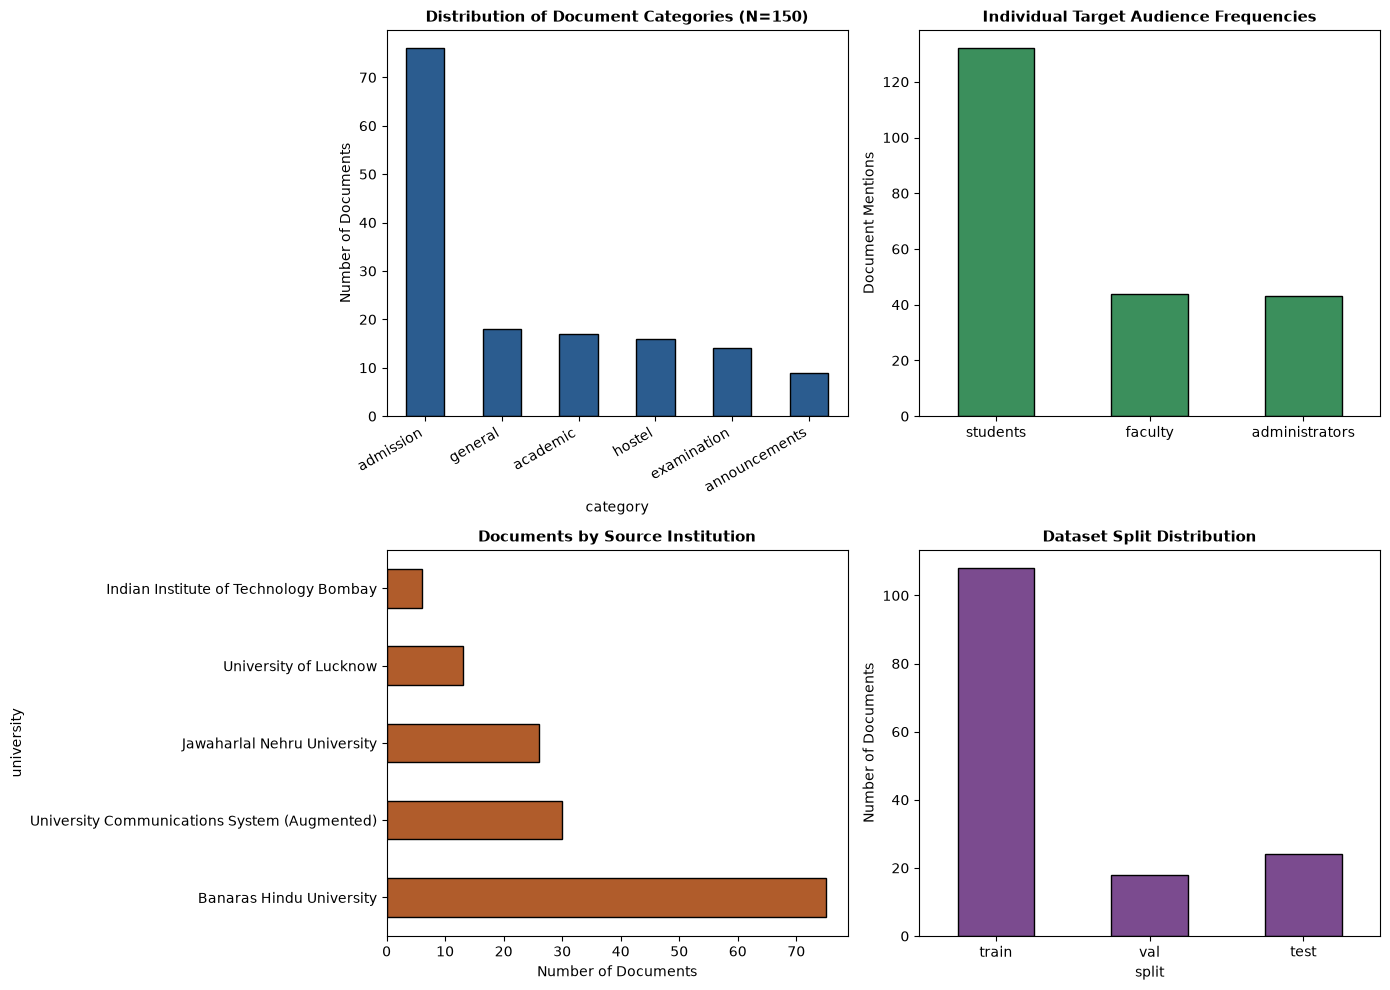

In [6]:
plt.figure(figsize=(14, 10))

# 1. Category Distribution
plt.subplot(2, 2, 1)
cat_counts = df["category"].value_counts()
cat_counts.plot(kind="bar", color="#2b5c8f", edgecolor="black")
plt.title("Distribution of Document Categories (N=150)", fontsize=11, fontweight="bold")
plt.ylabel("Number of Documents")
plt.xticks(rotation=30, ha="right")

# 2. Audience Role Frequencies (Multi-label)
plt.subplot(2, 2, 2)
all_audiences = [role for sublist in df["audience_list"] for role in sublist]
aud_series = pd.Series(all_audiences).value_counts()
aud_series.plot(kind="bar", color="#3b8f5c", edgecolor="black")
plt.title("Individual Target Audience Frequencies", fontsize=11, fontweight="bold")
plt.ylabel("Document Mentions")
plt.xticks(rotation=0)

# 3. Documents per University
plt.subplot(2, 2, 3)
uni_counts = df["university"].value_counts()
uni_counts.plot(kind="barh", color="#b05c2b", edgecolor="black")
plt.title("Documents by Source Institution", fontsize=11, fontweight="bold")
plt.xlabel("Number of Documents")

# 4. Data Partitioning (Split)
plt.subplot(2, 2, 4)
split_counts = df["split"].value_counts()[["train", "val", "test"]]
split_counts.plot(kind="bar", color="#7b4b8f", edgecolor="black")
plt.title("Dataset Split Distribution", fontsize=11, fontweight="bold")
plt.ylabel("Number of Documents")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


### 7. Train / Validation / Test Partitioning & Leakage Prevention
To ensure rigorous evaluation:
1. **Real documents were split first** using stratified category sampling into Train (78), Validation (18), and Test (24).
2. **Synthetic augmentations (30 notices) were added exclusively to the Training set**.
3. **Validation and Test sets are 100% real documents** (0 synthetic records).
4. No document ID appears in more than one partition.


In [7]:
# Verify split integrity and non-leakage assertions
train_ids = set(df[df["split"] == "train"]["document_id"])
val_ids = set(df[df["split"] == "val"]["document_id"])
test_ids = set(df[df["split"] == "test"]["document_id"])

# 1. No ID overlap
assert not (train_ids & val_ids), "ERROR: Train and Val share document IDs!"
assert not (train_ids & test_ids), "ERROR: Train and Test share document IDs!"
assert not (val_ids & test_ids), "ERROR: Val and Test share document IDs!"

# 2. Synthetic documents strictly confined to train
synth_non_train = df[(df["split"] != "train") & (df["is_synthetic"] == True)]
assert len(synth_non_train) == 0, "ERROR: Synthetic documents leaked into validation/test!"

# 3. Validation and Test must be 100% real documents
assert df[df["split"] == "val"]["is_synthetic"].sum() == 0, "Validation contains synthetic data!"
assert df[df["split"] == "test"]["is_synthetic"].sum() == 0, "Test contains synthetic data!"

print("ALL LEAKAGE INTEGRITY CHECKS PASSED:")
print(f" - Train Set: {len(train_ids)} documents (78 real + 30 synthetic)")
print(f" - Validation Set: {len(val_ids)} documents (100% REAL)")
print(f" - Test Set: {len(test_ids)} documents (100% REAL)")


ALL LEAKAGE INTEGRITY CHECKS PASSED:
 - Train Set: 108 documents (78 real + 30 synthetic)
 - Validation Set: 18 documents (100% REAL)
 - Test Set: 24 documents (100% REAL)


### 8. Dataset Summary Table
The table below summarizes the key attributes of the canonical classification dataset:


In [8]:
summary_table = pd.DataFrame([
    {"Property": "Total documents", "Value": str(len(df))},
    {"Property": "Real documents", "Value": str((~df["is_synthetic"]).sum())},
    {"Property": "Synthetic documents", "Value": str(df["is_synthetic"].sum())},
    {"Property": "Training", "Value": str((df["split"] == "train").sum())},
    {"Property": "Validation", "Value": str((df["split"] == "val").sum())},
    {"Property": "Test", "Value": str((df["split"] == "test").sum())},
    {"Property": "Category classes", "Value": str(df["category"].nunique())},
    {"Property": "Audience classes", "Value": "3 (students, faculty, administrators)"},
])

summary_table.set_index("Property")


,Value
Property,
Total documents,150
Real documents,120
Synthetic documents,30
Training,108
Validation,18
Test,24
Category classes,6
Audience classes,"3 (students, faculty, administrators)"


### Conclusion
The preprocessed, quality-audited dataset is stored at `data/processed/classification_dataset/classification_dataset.csv`. It serves as the single source of truth for both the Category Classification and Audience Classification baseline models demonstrated in `02_baseline_models.ipynb`.
